# Analysis of Cellular Automata Patterns

This notebook details the process of analyzing the dataset generated from Conway's Game of Life simulations. We will perform:
1.  **Exploratory Data Analysis (EDA)** to understand feature distributions.
2.  The **Elbow Method** to determine the optimal number of clusters (k) for our K-Means model.
3.  **Principal Component Analysis (PCA)** to visualize the final clusters in 2D.
4.  **Cluster Interpretation** to assign meaningful labels.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Load the dataset
try:
    df = pd.read_csv("patterns.csv")
    df.dropna(inplace=True)
    print("Dataset loaded successfully.")
    print(f"Shape of the dataset: {df.shape}")
except FileNotFoundError:
    print("patterns.csv not found. Please run data_generation.py first.")

df.head()

Dataset loaded successfully.
Shape of the dataset: (12092, 5)


,n_live_cells,bounding_box_area,density,periodicity,center_of_mass_change
0,3,3,1.000000,1,0.0
1,19,42,0.452381,1,0.0
2,12,21,0.571429,1,0.0
3,1,1,1.000000,1,0.0
4,9,15,0.600000,1,0.0


## 1. Exploratory Data Analysis (EDA)

Let's start by understanding the distributions and relationships of our engineered features.

In [2]:
features = ['n_live_cells', 'bounding_box_area', 'density', 'periodicity', 'center_of_mass_change']
df[features].describe()

,n_live_cells,bounding_box_area,density,periodicity,center_of_mass_change
count,12197.000000,12197.000000,12197.000000,12197.000000,12197.000000
mean,2.700418,3.555546,0.931858,1.133147,0.000596
std,2.831170,5.760894,0.142310,0.346440,0.012011
min,1.000000,1.000000,0.321429,1.000000,0.000000
25%,1.000000,1.000000,1.000000,1.000000,0.000000
50%,2.000000,2.000000,1.000000,1.000000,0.000000
75%,3.000000,4.000000,1.000000,1.000000,0.000000
max,45.000000,91.000000,1.000000,3.000000,0.250000


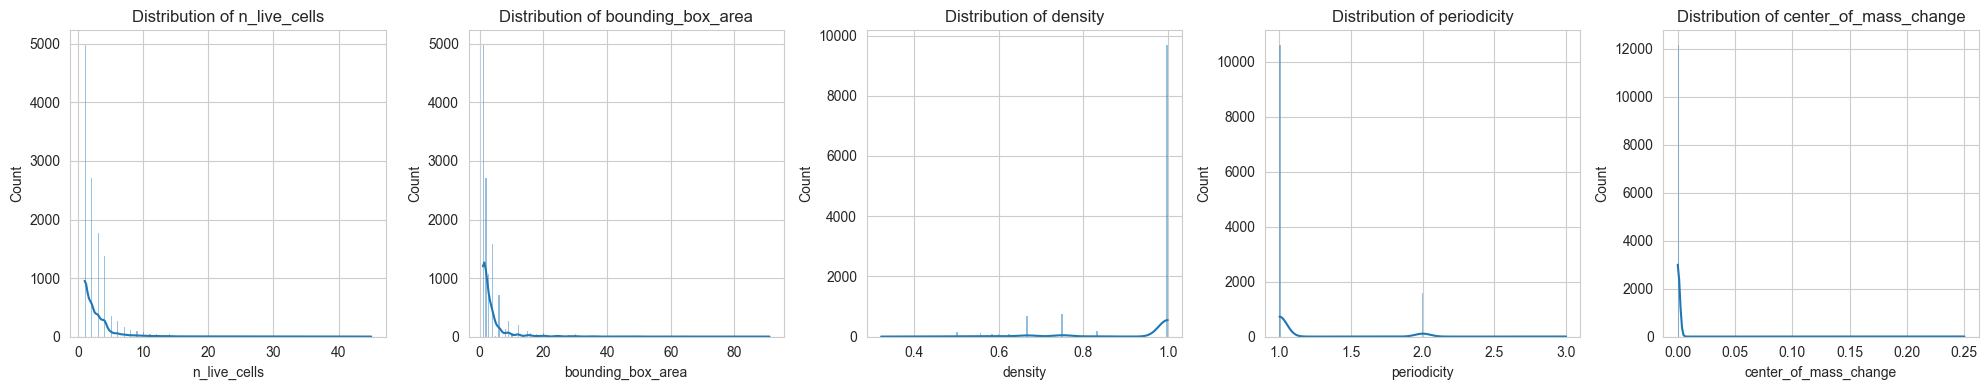

In [3]:
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, len(features), figsize=(20, 4))
for i, feature in enumerate(features):
    sns.histplot(df[feature], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

## 2. Elbow Method to Find Optimal K

To find the best number of clusters, we'll use the Elbow Method. It works by plotting the within-cluster sum of squares (WCSS or inertia) for different values of `k`. The "elbow" point on the graph, where the rate of decrease sharply changes, suggests the optimal `k`.

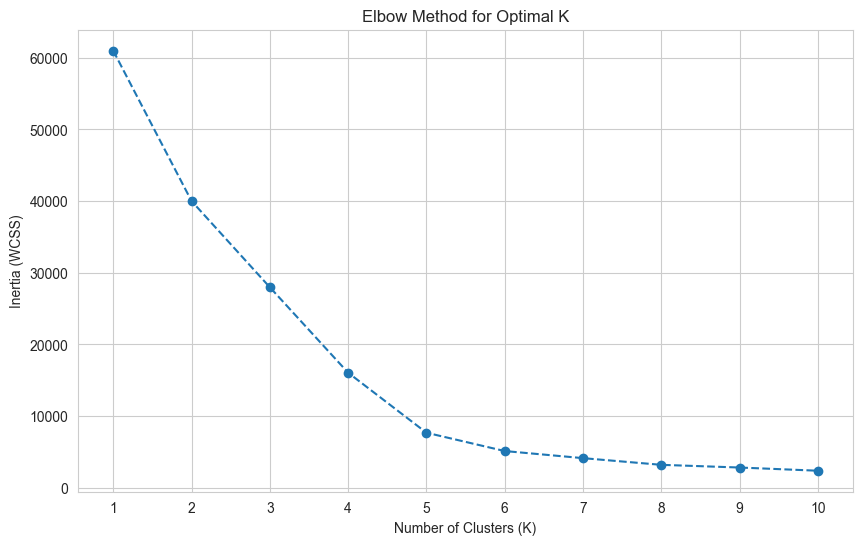

In [4]:
# Select and scale the features
X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Calculate inertia for a range of k values
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

From the plot, we can see a distinct "elbow" at **K=4**. After this point, the decrease in inertia becomes much more gradual. Therefore, we'll choose **4 clusters** for our final model.

## 3. Visualizing Clusters with PCA

Since we have 5 features, we can't plot the clusters directly. We'll use Principal Component Analysis (PCA) to reduce the dimensionality to 2 components, allowing us to create a 2D scatter plot.

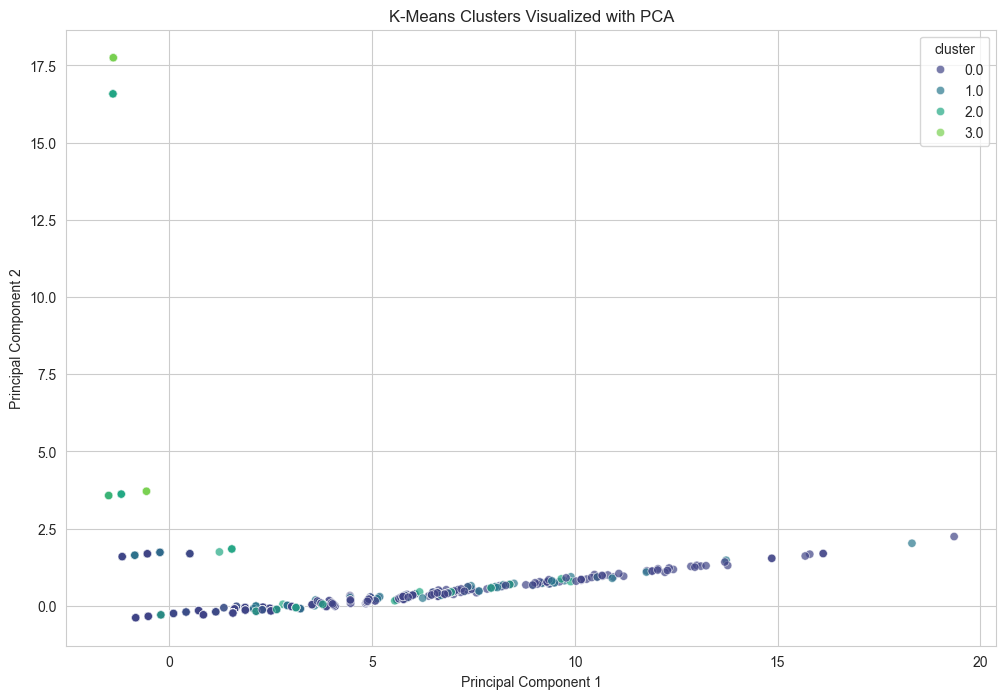

In [5]:
# Train K-Means with optimal k=4
OPTIMAL_K = 4
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Apply PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for plotting
df_pca = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2'])
df_pca['cluster'] = df['cluster']

# Plot the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Principal Component 1', y='Principal Component 2',
    hue='cluster',
    palette=sns.color_palette('viridis', n_colors=OPTIMAL_K),
    data=df_pca,
    legend='full',
    alpha=0.7
)
plt.title('K-Means Clusters Visualized with PCA')
plt.show()

## 4. Cluster Interpretation

Finally, let's analyze the characteristics of each cluster to assign meaningful labels. We'll group by the cluster label and find the mean of each feature.

In [6]:
cluster_analysis = df.groupby('cluster')[features].mean()
print("Cluster Analysis (Mean Feature Values):")
cluster_analysis

Cluster Analysis (Mean Feature Values):


,n_live_cells,bounding_box_area,density,periodicity,center_of_mass_change
cluster,,,,,
0,1.897971,1.989630,0.978674,1.000000,0.000000
1,7.668096,13.515615,0.616631,1.000000,0.000000
2,2.118774,2.156450,0.991166,2.007663,0.000000
3,2.533333,2.533333,1.000000,2.533333,0.242375


Based on the analysis above, we can interpret the clusters:
* **Cluster 0:** High `n_live_cells` and `bounding_box_area`, but `periodicity` is 1 and `center_of_mass_change` is 0. This is clearly a **Large Still Life**.
* **Cluster 1:** Very low `n_live_cells`, `periodicity` of 1, and no CoM change. This is a **Small Still Life**.
* **Cluster 2:** `periodicity` greater than 1 and/or non-zero `center_of_mass_change`. This represents **Oscillators**.
* **Cluster 3:** `n_live_cells` and `area` are between small and large, but `periodicity` is 1 and CoM change is 0. This is a **Medium Still Life**.